## Synthetic spectra generation (H2–He sub-Neptune / K2-18b analogue)

A grid of synthetic transmission spectra is generated for a **sub-Neptune** case
(labelled in the notebook as a **K2-18b analogue**).

### Atmosphere (primary)
- Bulk composition: **H2–He** (CIA terms: **H2–H2** and **H2–He**).
- Pressure bounds are fixed to:
  - Base pressure: **10 bar** (implemented as `base_pressure=10e5` Pa = `1e6` Pa).
  - Top pressure: **1e-8 bar** (implemented as `top_pressure=1e-3` Pa).

### Temperature grid 
The explored atmospheric temperatures are:
- **[250, 300, 350, 400, 450] K**

### Trace gases and explored log10(VMR) ranges
The following trace gases are included (log10 volume mixing ratios):
- **H2O**: from **-7 to -2**, with **absence allowed** (`include_absence=True`)
- **CO2**: from **-10 to -1**
- **CH4**: from **-8 to -1**, with **absence allowed**
- **NH3**: from **-7 to -2**, with **absence allowed**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import multirex as mrex

mrex.Util.get_gases()
mrex.Util.get_stellar_phoenix()
mrex.Util.list_gases()


Numba not installed, using numpy instead
Loading MultiREx version 0.3.1


Downloading...
From (original): https://drive.google.com/uc?id=1z7R0hD1IBuYo-nnl7dpE_Ls2337a0uv6
From (redirected): https://drive.google.com/uc?id=1z7R0hD1IBuYo-nnl7dpE_Ls2337a0uv6&confirm=t&uuid=7d732a20-5615-464e-a54f-238e15c49eef
To: c:\Proyectos\Maestría\AEspectra\exp 3\opacidades-todas.zip
100%|██████████| 2.12G/2.12G [10:24<00:00, 3.40MB/s]


The path where the Phoenix stellar spectra will be downloaded is :  current directory


Downloading...
From (original): https://drive.google.com/uc?id=1fgKjDu9H26y5WMwRZaMCuSpHhx8zc0pR
From (redirected): https://drive.google.com/uc?id=1fgKjDu9H26y5WMwRZaMCuSpHhx8zc0pR&confirm=t&uuid=04e95e41-86b8-412e-b97e-bc22bf4f251b
To: c:\Proyectos\Maestría\AEspectra\exp 3\Phoenix.zip
100%|██████████| 2.46G/2.46G [01:31<00:00, 26.9MB/s]


Available gases in the database:
['C2H6', 'CO', 'NO2', 'N2', 'NH3', 'CO2', 'H2O', 'CH4', 'CH3Cl', 'O3', 'O2', 'HCN', 'SO2', 'DMS']


In [5]:
star = mrex.Star(
    temperature=3500,
    radius=0.468,
    mass=0.495,
    phoenix_path="",
)

planet = mrex.Planet(
    radius=2.461,
    mass=7.2,
)

atm_h2he = mrex.Atmosphere(
    temperature=250,
    base_pressure=10e5,   # Pa = 10 bar
    top_pressure=1e-3,    # Pa = 1e-8 bar
    fill_gas=["H2", "He"],
    cia=["H2-H2", "H2-He"],
)

planet.set_atmosphere(atm_h2he)

system_h2 = mrex.System(
    planet=planet,
    star=star,
    sma=0.1429,
)

mrex.Util.get_CIAs(["H2-H2", "H2-He"], path="CIA")

system_h2.make_tm()


The directory to Phoenix already exists in the specified path:  current directory


In [6]:
# Load PandExo wavelength grid (μm), then convert to wavenumbers (cm^-1).
waves_um = np.loadtxt("waves.txt").astype(float)

# The original code keeps all points (indices cover the full range).
n_points = len(waves_um)
indices = np.linspace(0, n_points - 1, n_points, endpoint=True)
indices = np.round(indices).astype(int)

waves_um = waves_um[indices]
wn_grid = np.sort(10000.0 / waves_um)

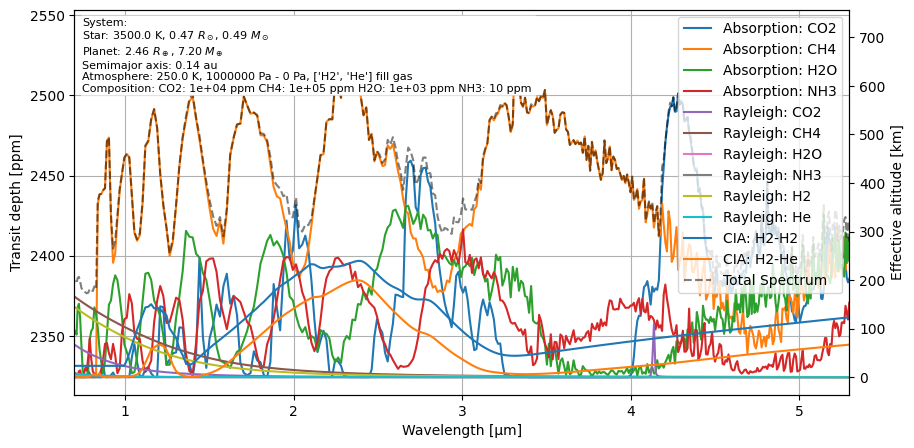

(<Figure size 1000x500 with 2 Axes>,
 <Axes: xlabel='Wavelength [μm]', ylabel='Transit depth [ppm]'>)

In [7]:
# Example trace gas configuration (single run before building the full grid).
system_h2.planet.atmosphere.add_gas("CO2", -2)
system_h2.planet.atmosphere.add_gas("CH4", -1)
system_h2.planet.atmosphere.add_gas("H2O", -3)
system_h2.planet.atmosphere.add_gas("NH3", -5)

system_h2.make_tm()
system_h2.plot_contributions(wn_grid)

## Contribution plot with H2–H2 masking

## Espectros

Se generarán con trappist 1e, pero podemos también usar la Tierra orbitando una M9.

Parámetros básicos del sistema, a revisar el rango del NIrspec Prism, tal vez mejor tomar todos los puntos del espectro

In [9]:
from taurex.binning import FluxBinner

tm = system_h2.transmission
nus = wn_grid  # cm^-1

tm_full_contrib=(tm.model_full_contrib(nus))
bn = FluxBinner(nus)

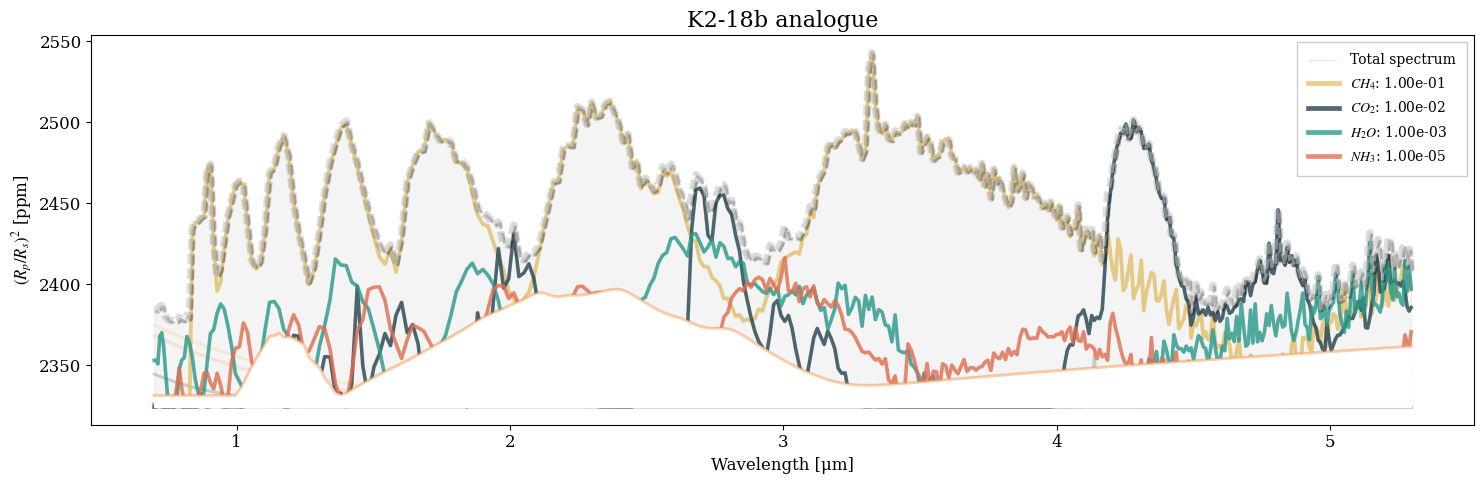

In [10]:
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# --- Styling ---
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["font.size"] = 12

palette = {
    "dark_blue": "#264653",
    "teal": "#2A9D8F",
    "sandy": "#F4A261",
    "yellow": "#E9C46A",
    "burnt_red": "#E76F51",
    "grey_alpha": "#cccccc80",
}


target_gases = ["CH4", "CO2", "H2O", "NH3"]
gas_colors = {
    "CO2": palette["dark_blue"],
    "H2O": palette["teal"],
    "CH4": palette["yellow"],
    "NH3": palette["burnt_red"],
}

mixing_exp = {"CO2": -2, "CH4": -1, "H2O": -3, "NH3": -5}
gas_tex = {"CO2": r"$CO_2$", "H2O": r"$H_2O$", "CH4": r"$CH_4$", "NH3": r"$NH_3$"}


def exp_to_str(exp: float) -> str:
    return f"{10.0 ** exp:.2e}"


fill_color = palette["sandy"]


# --- Helpers to read the contribution object ---
def _get_group(contrib, key: str):
    for k in contrib[1].keys():
        if str(k).strip().lower() == str(key).strip().lower():
            return contrib[1][k]
    return None


def _find_item_by_label(group, label: str):
    if group is None:
        return None
    for it in group:
        if str(it[0]).strip() == str(label).strip():
            return it
    return None


def get_array(contrib, mech: str, label: str):
    group = _get_group(contrib, mech)
    if group is None:
        return None

    if hasattr(group, "keys"):  # dict
        return np.array(group[label], float) if label in group else None

    it = _find_item_by_label(group, label)  # list
    return np.array(it[1], float) if it is not None else None


def get_template_meta(contrib):
    abs_group = _get_group(contrib, "Absorption")
    if abs_group is not None and not hasattr(abs_group, "keys") and len(abs_group) > 0:
        it = abs_group[0]
        return it[2], it[3]

    cia_group = _get_group(contrib, "CIA")
    if cia_group is not None and not hasattr(cia_group, "keys") and len(cia_group) > 0:
        it = cia_group[0]
        return it[2], it[3]

    raise ValueError("Could not infer meta2/meta3 from Absorption or CIA groups.")


def iter_cia_terms(contrib):
    cia_group = _get_group(contrib, "CIA")
    out = []

    if cia_group is None:
        return out

    if hasattr(cia_group, "keys"):
        for name, arr in cia_group.items():
            out.append((str(name), np.array(arr, float)))
        return out

    for it in cia_group:
        out.append((str(it[0]), np.array(it[1], float)))
    return out


# -------------------------------------------------------------------------
# Required objects (used exactly as in your snippet):
# - tm_full_contrib
# - bn
# -------------------------------------------------------------------------
meta2, meta3 = get_template_meta(tm_full_contrib)

# --- Precompute: total spectrum ---
nus_tot, rp_rs_tot, *_ = bn.bin_model(tm.model(nus))
wl_tot = 1e4 / nus_tot
tot_ppm = 1e6 * rp_rs_tot

# --- Precompute: individual components ---
species_abs = []
species_ray = []
mins = [np.nanmin(tot_ppm)]

for mol in target_gases:
    abs_arr = get_array(tm_full_contrib, "Absorption", mol)
    ray_arr = get_array(tm_full_contrib, "Rayleigh", mol)

    if abs_arr is not None:
        obj = [tm_full_contrib[0], abs_arr, meta2, meta3]
        nus_m, rp_rs_m, *_ = bn.bin_model(obj)
        species_abs.append((mol, 1e4 / nus_m, 1e6 * rp_rs_m))
        mins.append(np.nanmin(1e6 * rp_rs_m))

    if ray_arr is not None:
        obj = [tm_full_contrib[0], ray_arr, meta2, meta3]
        nus_r, rp_rs_r, *_ = bn.bin_model(obj)
        species_ray.append((mol, 1e4 / nus_r, 1e6 * rp_rs_r))
        mins.append(np.nanmin(1e6 * rp_rs_r))

# --- Fill gases + find H2-H2 CIA curve (for masking) ---
fill_curves = []
h2h2_curve = None

for name, arr in iter_cia_terms(tm_full_contrib):
    obj = [tm_full_contrib[0], arr, meta2, meta3]
    nus_c, rp_rs_c, *_ = bn.bin_model(obj)

    wl_c = 1e4 / nus_c
    y_c = 1e6 * rp_rs_c
    fill_curves.append((wl_c, y_c))
    mins.append(np.nanmin(y_c))

    if "H2-H2" in name:
        h2h2_curve = (wl_c, y_c)

for fg in ["H2", "He"]:
    arr = get_array(tm_full_contrib, "Rayleigh", fg)
    if arr is None:
        continue

    obj = [tm_full_contrib[0], arr, meta2, meta3]
    nus_r, rp_rs_r, *_ = bn.bin_model(obj)
    fill_curves.append((1e4 / nus_r, 1e6 * rp_rs_r))
    mins.append(np.nanmin(fill_curves[-1][1]))

ymin_global = float(np.nanmin(mins))

# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 5))

# 1) Fill gases background
for wl_f, y_f in fill_curves:
    ax.plot(wl_f, y_f, color=fill_color, lw=2.4, alpha=0.22, zorder=1, label="_nolegend_")

# 2) Rayleigh background for species
for mol, wl_r, y_r in species_ray:
    color = gas_colors.get(mol, palette["dark_blue"])
    ax.plot(wl_r, y_r, color=color, lw=2.2, alpha=0.22, zorder=1, label="_nolegend_")

# 3) Absorption species curves
for mol, wl_m, y_m in species_abs:
    color = gas_colors.get(mol, palette["dark_blue"])
    line, = ax.plot(wl_m, y_m, color=color, lw=2.5, alpha=0.8, zorder=2)
    line.set_path_effects([pe.Stroke(linewidth=2.8, foreground="#00000018"), pe.Normal()])

# 4) H2-H2 mask (white fill up to the H2-H2 CIA curve)
if h2h2_curve is not None:
    wl_h2, y_h2 = h2h2_curve
    ax.fill_between(wl_h2, ymin_global, y_h2, color="white", alpha=1.0, zorder=10)
    ax.plot(wl_h2, y_h2, color=fill_color, lw=2, alpha=0.5, zorder=10.1)

# 5) Total spectrum on top
ax.fill_between(wl_tot, ymin_global, tot_ppm, color=palette["grey_alpha"], alpha=0.20, zorder=0)

tot_line, = ax.plot(wl_tot, tot_ppm, color=palette["grey_alpha"], lw=2, ls="--", zorder=11)
tot_line.set_path_effects(
    [
        pe.SimpleLineShadow(offset=(1.2, -1.2), alpha=0.25),
        pe.Stroke(linewidth=5.6, foreground="#00000022"),
        pe.Normal(),
    ]
)

# Legend
handles = [Line2D([0], [0], color=palette["grey_alpha"], lw=1.0, ls="--")]
labels = ["Total spectrum"]

for gas in ["CH4", "CO2", "H2O", "NH3"]:
    handles.append(Line2D([0], [0], color=gas_colors[gas], lw=3.4, ls="-", alpha=0.8))
    labels.append(f"{gas_tex[gas]}: {exp_to_str(mixing_exp[gas])}")

ax.legend(
    handles=handles,
    labels=labels,
    loc="best",
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    borderpad=0.8,
    labelspacing=0.55,
    handlelength=2.2,
    handletextpad=0.8,
    fontsize="small",
)

ax.set_xlabel("Wavelength [μm]")
ax.set_ylabel(r"$(R_p/R_s)^2$ [ppm]")
ax.set_title("K2-18b analogue", fontsize=16)

plt.tight_layout()
#plt.savefig("K2-18b_spectrum_masked_top.png", dpi=500)
plt.show()


## Dataset

In [ ]:
parameter_space = {
    "planet.atmosphere.composition.NH3": {"min": -7, "max": -2, "n": 6, "include_absence": True},
    "planet.atmosphere.temperature": [250, 300, 350, 400, 450],
    "planet.atmosphere.composition.CH4": {"min": -8, "max": -1, "n": 8, "include_absence": True},
    "planet.atmosphere.composition.CO2": {"min": -10, "max": -1, "n": 10},
    "planet.atmosphere.composition.H2O": {"min": -7, "max": -2, "n": 6, "include_absence": True},
}

h2_data = system_h2.explore_parameter_space(
    wn_grid=wn_grid,
    parameter_space=parameter_space,
    header=True,
    observations=False,
    n_jobs=-1,
)

h2_data[["atm CO2", "atm H2O", "atm NH3", "atm CH4"]]


,atm CO2,atm H2O,atm NH3,atm CH4
0,-10.0,-7.0,-7.0,-8.0
1,-10.0,-6.0,-7.0,-8.0
2,-10.0,-5.0,-7.0,-8.0
3,-10.0,-4.0,-7.0,-8.0
4,-10.0,-3.0,-7.0,-8.0
...,...,...,...,...
22045,-1.0,-5.0,NaN,NaN
22046,-1.0,-4.0,NaN,NaN
22047,-1.0,-3.0,NaN,NaN
22048,-1.0,-2.0,NaN,NaN


In [ ]:
import joblib

joblib.dump(h2_data, "specs/K2-18b_data.joblib")

spectra = h2_data.data
headers = h2_data.params


## Quick inspection

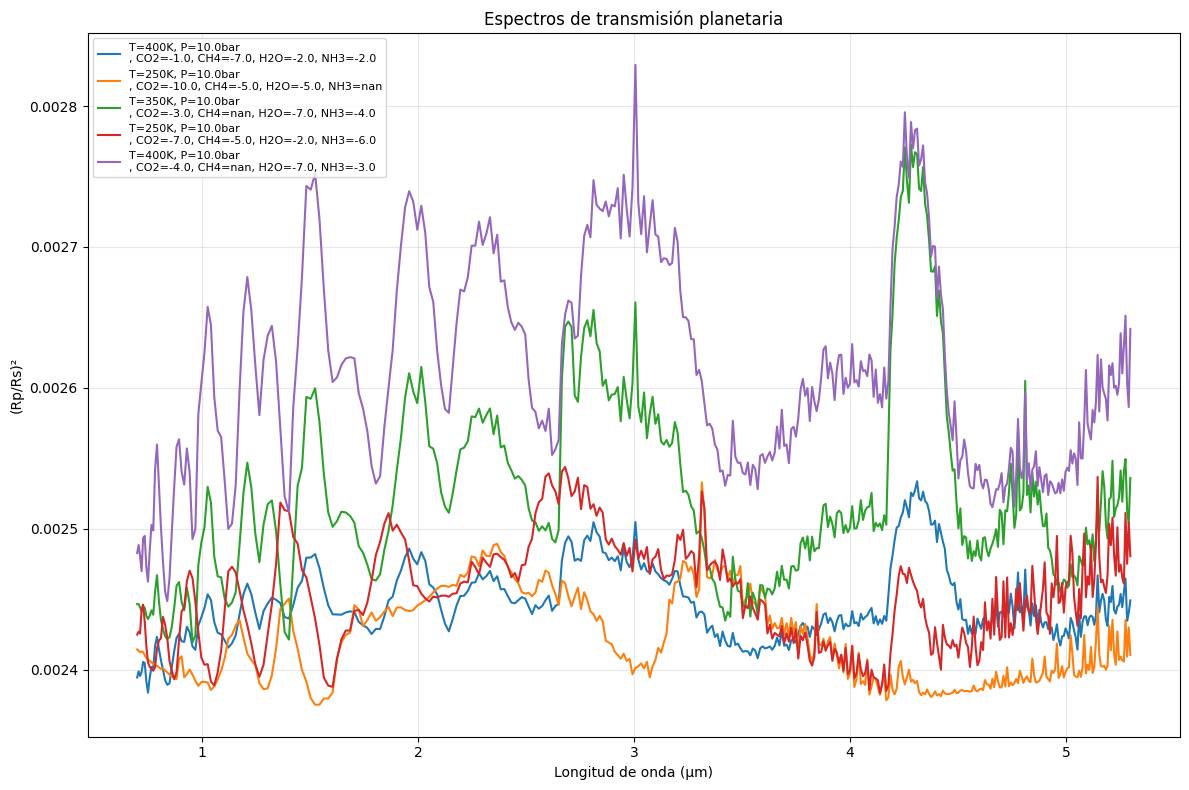

In [ ]:
import random

n_samples = 5
random_indices = random.sample(range(len(spectra)), n_samples)

wavelengths_um = [float(col) for col in spectra.columns]

plt.figure(figsize=(12, 8))

for idx in random_indices:
    spec_values = spectra.iloc[idx].values
    params = headers.iloc[idx]

    temp_k = params["atm temperature"]
    base_p_bar = params["atm base_pressure"] / 1e5  # Pa -> bar

    co2 = params["atm CO2"]
    ch4 = params["atm CH4"]
    h2o = params["atm H2O"]
    nh3 = params["atm NH3"]

    plt.plot(
        wavelengths_um,
        spec_values,
        label=(
            f"T={temp_k} K, P={base_p_bar:.1f} bar, "
            f"CO2={co2}, CH4={ch4}, H2O={h2o}, NH3={nh3}"
        ),
    )

plt.xlabel("Wavelength [μm]")
plt.ylabel(r"$(R_p/R_s)^2$")
plt.title("Synthetic transmission spectra (random sample)")
plt.legend(loc="best", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()